# Krok 1 — Exploratorní datová analýza (EDA)

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 1 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Načíst čtyři zdrojové sheety z `dataset.xlsx`, ověřit datovou kvalitu (chybějící hodnoty, duplicity, datové typy) a vizualizovat klíčové distribuce — order_value, věk zákazníků, loyalty tier a počet objednávek na zákazníka. Výstupy EDA budou podkladem pro feature engineering v Kroku 2.


## 2. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Konstanty
RANDOM_STATE = 42
DATA_PATH = Path("dataset.xlsx")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Seaborn styl
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Prostředí inicializováno.")
print(f"Pandas verze: {pd.__version__}")


Prostředí inicializováno.
Pandas verze: 3.0.2


## 3. Načtení dat

In [2]:
try:
    sheets = pd.read_excel(DATA_PATH, sheet_name=None)
    print(f"Načteno {len(sheets)} sheetů: {list(sheets.keys())}")
except FileNotFoundError:
    raise FileNotFoundError(f"Soubor {DATA_PATH} nebyl nalezen.")

df_account  = sheets["Account"]
df_orders   = sheets["Order__c"]
df_activity = sheets["Activity__c"]
df_product  = sheets["Product2"]

# Parsování datumů
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_activity["last_login_date"] = pd.to_datetime(df_activity["last_login_date"])
df_account["customer_since"] = pd.to_datetime(df_account["customer_since"])


Načteno 4 sheetů: ['Account', 'Order__c', 'Product2', 'Activity__c']


### 3.1 Sanity check — tvary a typy

In [3]:
for name, df in {
    "Account": df_account,
    "Order__c": df_orders,
    "Activity__c": df_activity,
    "Product2": df_product,
}.items():
    print(f"{'='*50}")
    print(f"Sheet: {name}  |  Shape: {df.shape}")
    print(df.dtypes.to_string())
    print()


Sheet: Account  |  Shape: (1200, 8)
account_external_id               str
account_name                      str
customer_since         datetime64[us]
region                            str
age                             int64
preferred_channel                 str
campaign_opt_in                  bool
loyalty_tier                      str

Sheet: Order__c  |  Shape: (9567, 12)
order_external_id                 str
account_external_id               str
order_date             datetime64[us]
product_external_id               str
quantity                        int64
unit_price                    float64
discount_used                    bool
discount_pct                    int64
order_value                   float64
product_category                  str
sales_channel                     str
order_status                      str

Sheet: Activity__c  |  Shape: (1200, 7)
account_external_id               str
last_login_date        datetime64[us]
login_count_30d                 int64
login_coun

### 3.2 Prvních 5 řádků každého sheetu

In [4]:
df_account.head()

,account_external_id,account_name,customer_since,region,age,preferred_channel,campaign_opt_in,loyalty_tier
0,ACC-00001,Customer 00001,2024-08-15,CZ,39,Store,False,Bronze
1,ACC-00002,Customer 00002,2023-09-22,CZ,48,Mobile App,True,Silver
2,ACC-00003,Customer 00003,2023-03-20,CZ,34,Email,False,Silver
3,ACC-00004,Customer 00004,2022-11-22,CZ,38,Store,True,Bronze
4,ACC-00005,Customer 00005,2023-12-28,CZ,29,Mobile App,True,Gold


In [5]:
df_orders.head()

,order_external_id,account_external_id,order_date,product_external_id,quantity,unit_price,discount_used,discount_pct,order_value,product_category,sales_channel,order_status
0,ORD-000001,ACC-00001,2024-11-10,PROD-0053,1,1488.74,False,0,1488.74,Beauty,Store,Completed
1,ORD-000002,ACC-00002,2023-10-17,PROD-0020,1,5239.23,True,15,4453.35,Home,Mobile App,Returned
2,ORD-000003,ACC-00002,2024-03-02,PROD-0036,3,3377.72,True,10,9119.84,Fashion,Mobile App,Completed
3,ORD-000004,ACC-00002,2024-05-26,PROD-0023,1,3568.11,False,0,3568.11,Home,Mobile App,Completed
4,ORD-000005,ACC-00002,2024-07-15,PROD-0050,1,522.61,True,10,470.35,Beauty,Mobile App,Completed


In [6]:
df_activity.head()

,account_external_id,last_login_date,login_count_30d,login_count_90d,email_open_rate,app_usage_score,support_tickets
0,ACC-00001,2024-12-11,6,14,0.29,39.3,4
1,ACC-00002,2024-09-23,11,39,0.24,53.8,4
2,ACC-00003,2024-12-02,7,19,0.20,12.3,3
3,ACC-00004,2024-11-04,5,11,0.05,17.3,3
4,ACC-00005,2024-10-01,21,55,0.62,88.4,1


In [7]:
df_product.head()

,product_external_id,product_name,category,list_price,unit_cost,is_active
0,PROD-0001,Arco Electronics 1,Electronics,2759.09,1951.71,True
1,PROD-0002,Aster Electronics 2,Electronics,8733.75,6015.31,True
2,PROD-0003,Mira Electronics 3,Electronics,17636.83,11070.70,True
3,PROD-0004,Nova Electronics 4,Electronics,9768.49,4628.08,True
4,PROD-0005,Lume Electronics 5,Electronics,5929.24,3646.25,True


## 4. Kontrola kvality dat

### 4.1 Chybějící hodnoty

In [8]:
def missing_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Vrátí DataFrame se souhrnem chybějících hodnot pro daný sheet."""
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df) * 100).round(2)
    summary = pd.DataFrame({
        "Sheet": name,
        "Sloupec": df.columns,
        "Chybí (počet)": missing_count.values,
        "Chybí (%)": missing_pct.values,
    }).query("`Chybí (počet)` > 0")
    return summary

missing_frames = [
    missing_summary(df_account,  "Account"),
    missing_summary(df_orders,   "Order__c"),
    missing_summary(df_activity, "Activity__c"),
    missing_summary(df_product,  "Product2"),
]

all_missing = pd.concat(missing_frames, ignore_index=True)

if all_missing.empty:
    print("✅ Žádné chybějící hodnoty v žádném sheetu.")
else:
    print(all_missing.to_string(index=False))


✅ Žádné chybějící hodnoty v žádném sheetu.


### 4.2 Duplicitní záznamy

In [9]:
dup_account  = df_account["account_external_id"].duplicated().sum()
dup_orders   = df_orders["order_external_id"].duplicated().sum()
dup_activity = df_activity["account_external_id"].duplicated().sum()
dup_product  = df_product["product_external_id"].duplicated().sum()

dup_summary = pd.DataFrame({
    "Sheet": ["Account", "Order__c", "Activity__c", "Product2"],
    "Klíčový sloupec": [
        "account_external_id", "order_external_id",
        "account_external_id", "product_external_id",
    ],
    "Duplicity": [dup_account, dup_orders, dup_activity, dup_product],
})
print(dup_summary.to_string(index=False))


      Sheet     Klíčový sloupec  Duplicity
    Account account_external_id          0
   Order__c   order_external_id          0
Activity__c account_external_id          0
   Product2 product_external_id          0


### 4.3 Popisné statistiky — numerické sloupce

In [10]:
print("=== Account ===")
display(df_account[["age"]].describe().round(2))

print("\n=== Order__c ===")
display(
    df_orders[["order_value", "quantity", "unit_price", "discount_pct"]]
    .describe()
    .round(2)
)

print("\n=== Activity__c ===")
display(
    df_activity[
        ["login_count_30d", "login_count_90d",
         "email_open_rate", "app_usage_score", "support_tickets"]
    ]
    .describe()
    .round(2)
)

print("\n=== Product2 ===")
display(df_product[["list_price", "unit_cost"]].describe().round(2))


=== Account ===


,age
count,1200.00
mean,35.62
std,10.34
min,18.00
25%,28.00
50%,35.00
75%,43.00
max,69.00



=== Order__c ===


,order_value,quantity,unit_price,discount_pct
count,9567.00,9567.00,9567.00,9567.00
mean,6238.95,1.47,4336.81,3.73
std,7313.60,0.72,3966.86,5.58
min,107.00,1.00,117.18,0.00
25%,2069.18,1.00,1803.88,0.00
50%,4016.88,1.00,3216.19,0.00
75%,7389.08,2.00,5518.58,5.00
max,90930.04,4.00,25311.07,20.00



=== Activity__c ===


,login_count_30d,login_count_90d,email_open_rate,app_usage_score,support_tickets
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,8.06,25.18,0.33,47.89,2.33
std,5.57,11.21,0.20,20.22,1.73
min,0.00,5.00,0.00,10.00,0.00
25%,5.00,17.00,0.18,34.48,1.00
50%,7.00,24.00,0.29,47.10,2.00
75%,11.00,33.00,0.47,61.42,4.00
max,29.00,67.00,0.90,99.80,6.00



=== Product2 ===


,list_price,unit_cost
count,72.00,72.00
mean,3788.72,2329.63
std,3432.60,2103.19
min,166.79,98.19
25%,1587.65,937.48
50%,2988.30,1806.08
75%,5089.69,3032.77
max,17636.83,11070.70


### 4.4 Časový rozsah objednávek a distribuce CLV 2025

In [11]:
df_orders["year"] = df_orders["order_date"].dt.year

orders_per_year = (
    df_orders.groupby("year")
    .agg(pocet_objednavek=("order_external_id", "count"),
         celkova_hodnota=("order_value", "sum"))
    .round(0)
)
print("Objednávky dle roku:")
display(orders_per_year)

# Pouze Completed objednávky pro výpočet CLV
df_completed = df_orders[df_orders["order_status"] == "Completed"].copy()

clv_2025 = (
    df_completed[df_completed["year"] == 2025]
    .groupby("account_external_id")["order_value"]
    .sum()
)

n_buyers     = len(clv_2025)
n_non_buyers = 1200 - n_buyers
print(f"\nZákazníků, kteří nakoupili v 2025:    {n_buyers}")
print(f"Zákazníků, kteří nenakoupili v 2025:  {n_non_buyers}")
print(f"Podíl aktivních v 2025:               {n_buyers/1200:.1%}")


Objednávky dle roku:


,pocet_objednavek,celkova_hodnota
year,,
2022,2131,12970551.0
2023,2765,17490477.0
2024,2692,16660433.0
2025,1979,12566597.0



Zákazníků, kteří nakoupili v 2025:    561
Zákazníků, kteří nenakoupili v 2025:  639
Podíl aktivních v 2025:               46.8%


## 5. Vizualizace

### 5.1 Distribuce order_value (log škála)

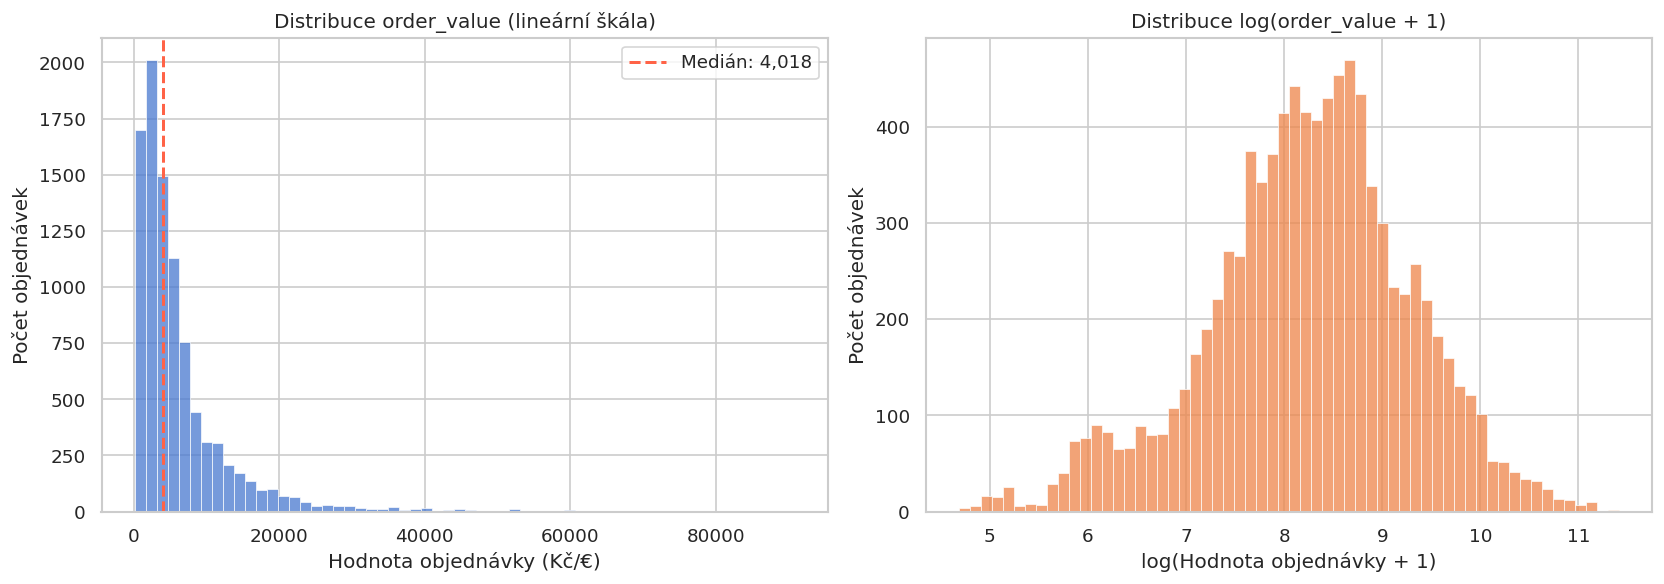

In [12]:
# Pouze Completed objednávky pro vizualizaci
completed_vals = df_completed["order_value"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — přirozená škála
sns.histplot(
    completed_vals,
    bins=60,
    ax=axes[0],
    color=sns.color_palette("muted")[0],
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_title("Distribuce order_value (lineární škála)")
axes[0].set_xlabel("Hodnota objednávky (Kč/€)")
axes[0].set_ylabel("Počet objednávek")
axes[0].axvline(completed_vals.median(), color="tomato", lw=1.8,
                linestyle="--", label=f"Medián: {completed_vals.median():,.0f}")
axes[0].legend()

# Histogram — log škála
sns.histplot(
    np.log1p(completed_vals),
    bins=60,
    ax=axes[1],
    color=sns.color_palette("muted")[1],
    edgecolor="white",
    linewidth=0.4,
)
axes[1].set_title("Distribuce log(order_value + 1)")
axes[1].set_xlabel("log(Hodnota objednávky + 1)")
axes[1].set_ylabel("Počet objednávek")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_order_value_dist.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Distribuce věku zákazníků

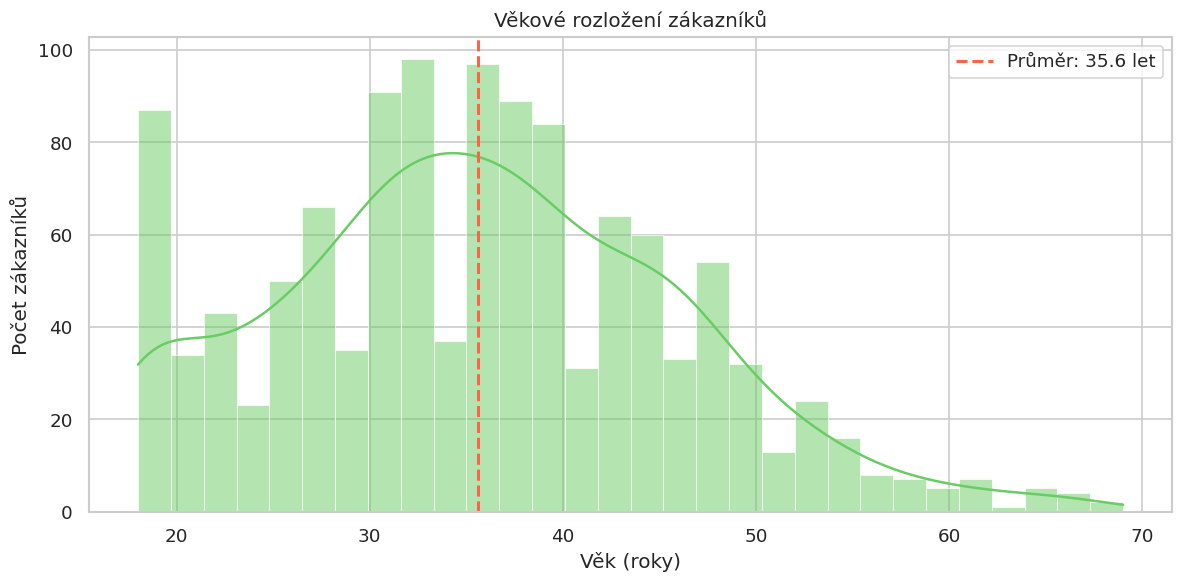

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df_account["age"],
    bins=30,
    ax=ax,
    color=sns.color_palette("muted")[2],
    edgecolor="white",
    linewidth=0.4,
    kde=True,
)
ax.set_title("Věkové rozložení zákazníků")
ax.set_xlabel("Věk (roky)")
ax.set_ylabel("Počet zákazníků")
ax.axvline(
    df_account["age"].mean(),
    color="tomato",
    lw=1.8,
    linestyle="--",
    label=f"Průměr: {df_account['age'].mean():.1f} let",
)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Počty zákazníků dle Loyalty Tier a Regionu

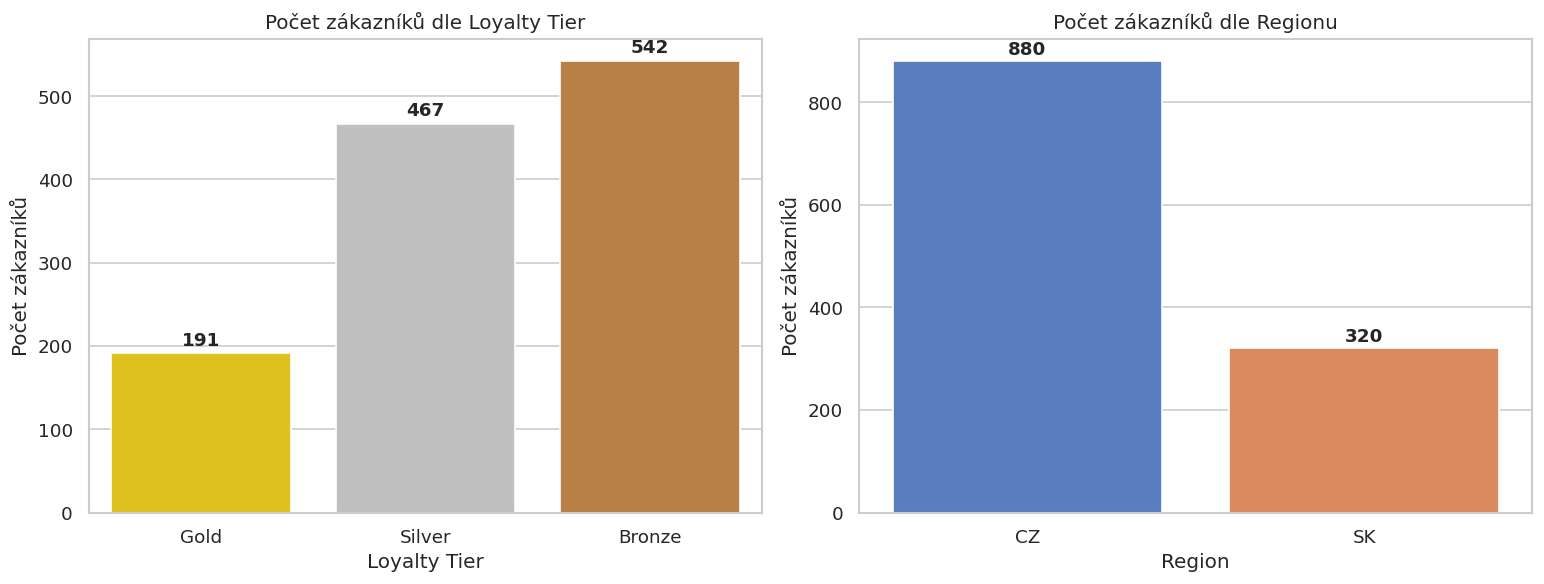

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

TIER_ORDER  = ["Gold", "Silver", "Bronze"]
TIER_COLORS = ["#FFD700", "#C0C0C0", "#CD7F32"]

# Loyalty tier
tier_counts = df_account["loyalty_tier"].value_counts().reindex(TIER_ORDER)
sns.barplot(
    x=tier_counts.index,
    y=tier_counts.values,
    ax=axes[0],
    palette=TIER_COLORS,
    order=TIER_ORDER,
)
axes[0].set_title("Počet zákazníků dle Loyalty Tier")
axes[0].set_xlabel("Loyalty Tier")
axes[0].set_ylabel("Počet zákazníků")
for bar, val in zip(axes[0].patches, tier_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Region
region_counts = df_account["region"].value_counts()
sns.barplot(
    x=region_counts.index,
    y=region_counts.values,
    ax=axes[1],
    palette=sns.color_palette("muted", n_colors=len(region_counts)),
)
axes[1].set_title("Počet zákazníků dle Regionu")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Počet zákazníků")
for bar, val in zip(axes[1].patches, region_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_tier_region.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Počet objednávek na zákazníka

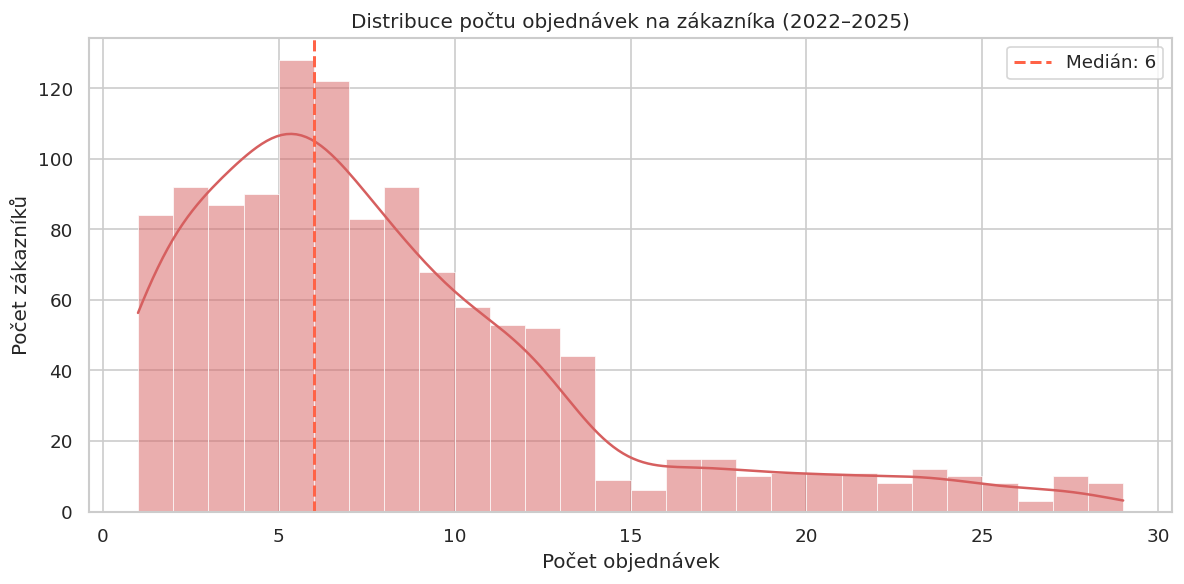

In [15]:
orders_per_customer = (
    df_orders.groupby("account_external_id")
    .size()
    .reset_index(name="order_count")
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    orders_per_customer["order_count"],
    bins=28,
    ax=ax,
    color=sns.color_palette("muted")[3],
    edgecolor="white",
    linewidth=0.4,
    kde=True,
)
ax.set_title("Distribuce počtu objednávek na zákazníka (2022–2025)")
ax.set_xlabel("Počet objednávek")
ax.set_ylabel("Počet zákazníků")
ax.axvline(
    orders_per_customer["order_count"].median(),
    color="tomato",
    lw=1.8,
    linestyle="--",
    label=f"Medián: {orders_per_customer['order_count'].median():.0f}",
)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_orders_per_customer.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Průměrná hodnota objednávky dle Loyalty Tier

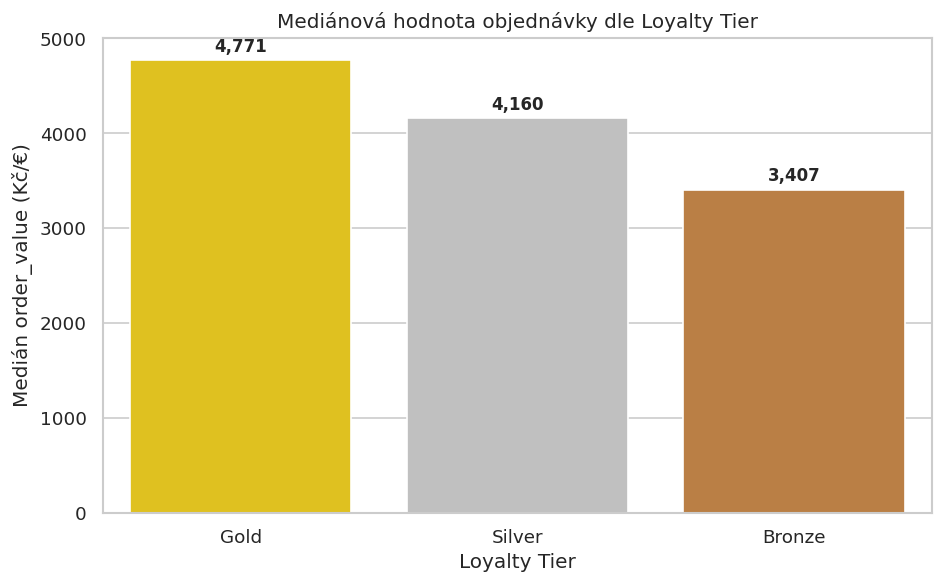

In [16]:
# Spojení objednávek s Account pro tier info
df_orders_acc = df_orders.merge(
    df_account[["account_external_id", "loyalty_tier"]],
    on="account_external_id",
    how="left",
)

tier_order_value = (
    df_orders_acc[df_orders_acc["order_status"] == "Completed"]
    .groupby("loyalty_tier")["order_value"]
    .median()
    .reindex(TIER_ORDER)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=tier_order_value,
    x="loyalty_tier",
    y="order_value",
    ax=ax,
    palette=TIER_COLORS,
    order=TIER_ORDER,
)
ax.set_title("Mediánová hodnota objednávky dle Loyalty Tier")
ax.set_xlabel("Loyalty Tier")
ax.set_ylabel("Medián order_value (Kč/€)")
for bar, val in zip(ax.patches, tier_order_value["order_value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{val:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_order_value_by_tier.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.6 Počet objednávek dle roku a sales channel

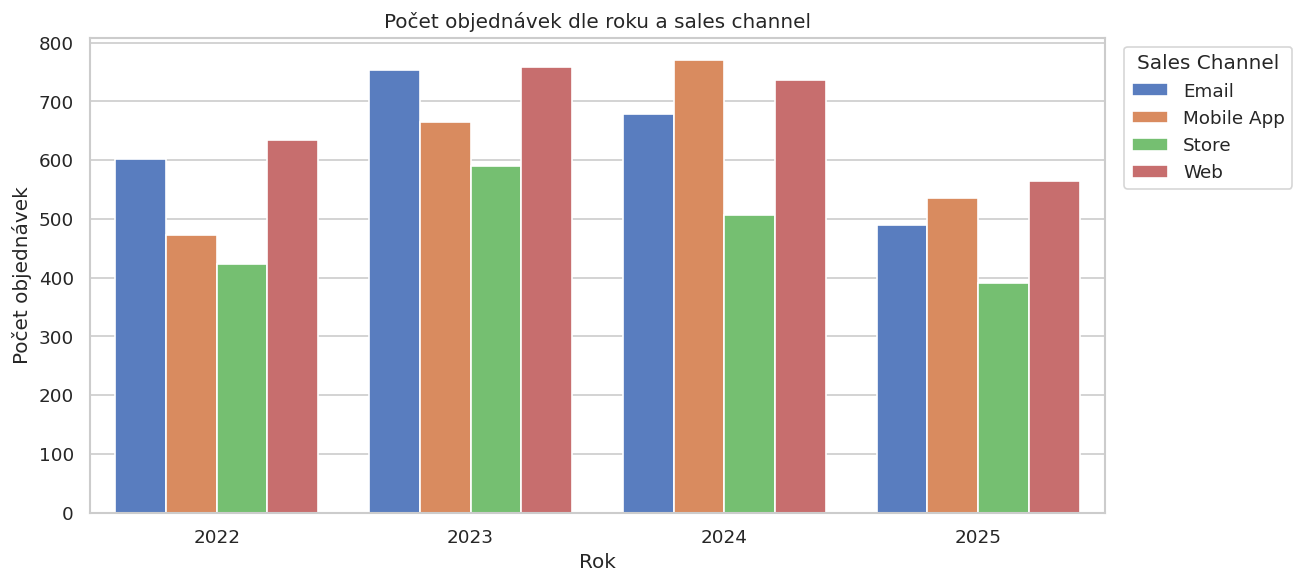

In [17]:
channel_year = (
    df_orders.groupby(["year", "sales_channel"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=channel_year,
    x="year",
    y="count",
    hue="sales_channel",
    ax=ax,
    palette="muted",
)
ax.set_title("Počet objednávek dle roku a sales channel")
ax.set_xlabel("Rok")
ax.set_ylabel("Počet objednávek")
ax.legend(title="Sales Channel", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_orders_by_channel_year.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.7 Distribuce CLV 2025 (u zákazníků, kteří nakoupili)

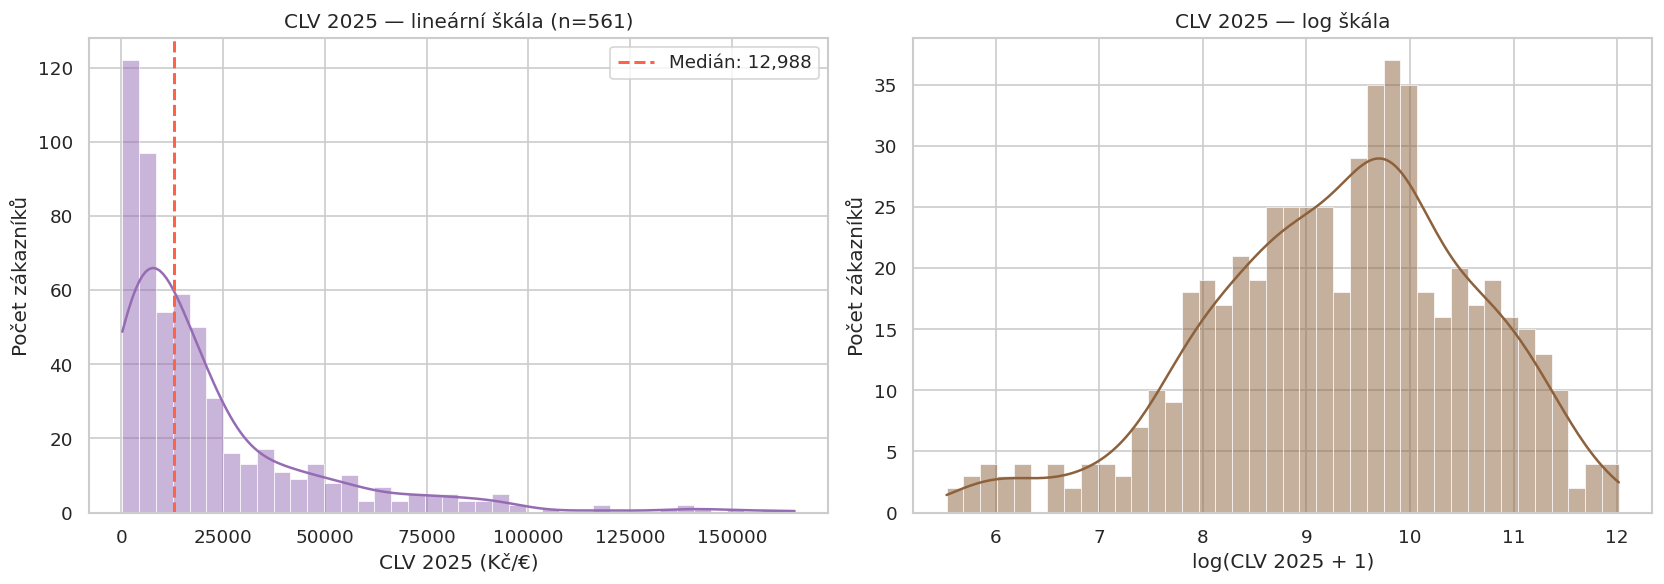

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lineární škála
sns.histplot(
    clv_2025,
    bins=40,
    ax=axes[0],
    color=sns.color_palette("muted")[4],
    edgecolor="white",
    linewidth=0.4,
    kde=True,
)
axes[0].set_title(f"CLV 2025 — lineární škála (n={len(clv_2025)})")
axes[0].set_xlabel("CLV 2025 (Kč/€)")
axes[0].set_ylabel("Počet zákazníků")
axes[0].axvline(
    clv_2025.median(),
    color="tomato",
    lw=1.8,
    linestyle="--",
    label=f"Medián: {clv_2025.median():,.0f}",
)
axes[0].legend()

# Log škála
sns.histplot(
    np.log1p(clv_2025),
    bins=40,
    ax=axes[1],
    color=sns.color_palette("muted")[5],
    edgecolor="white",
    linewidth=0.4,
    kde=True,
)
axes[1].set_title("CLV 2025 — log škála")
axes[1].set_xlabel("log(CLV 2025 + 1)")
axes[1].set_ylabel("Počet zákazníků")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_01_clv2025_dist.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Výsledky & Souhrn EDA

In [19]:
eda_summary = pd.DataFrame({
    "Metrika": [
        "Celkem zákazníků",
        "Celkem objednávek",
        "Celkem produktů",
        "Chybějící hodnoty (celkem)",
        "Duplicitní záznamy (celkem)",
        "Objednávky 2022",
        "Objednávky 2023",
        "Objednávky 2024",
        "Objednávky 2025",
        "Zákazníci aktivní v 2025",
        "Zákazníci neaktivní v 2025",
        "Průměrná order_value (Kč/€)",
        "Mediánová order_value (Kč/€)",
        "Průměrný věk zákazníka (roky)",
        "Průměrný CLV 2025 (aktivní, Kč/€)",
        "Mediánový CLV 2025 (aktivní, Kč/€)",
    ],
    "Hodnota": [
        1200,
        len(df_orders),
        len(df_product),
        all_missing["Chybí (počet)"].sum() if not all_missing.empty else 0,
        dup_account + dup_orders + dup_activity + dup_product,
        int(orders_per_year.loc[2022, "pocet_objednavek"]),
        int(orders_per_year.loc[2023, "pocet_objednavek"]),
        int(orders_per_year.loc[2024, "pocet_objednavek"]),
        int(orders_per_year.loc[2025, "pocet_objednavek"]),
        n_buyers,
        n_non_buyers,
        f"{df_completed['order_value'].mean():,.0f}",
        f"{df_completed['order_value'].median():,.0f}",
        f"{df_account['age'].mean():.1f}",
        f"{clv_2025.mean():,.0f}",
        f"{clv_2025.median():,.0f}",
    ],
})

display(eda_summary)


,Metrika,Hodnota
0,Celkem zákazníků,1200
1,Celkem objednávek,9567
2,Celkem produktů,72
3,Chybějící hodnoty (celkem),0
4,Duplicitní záznamy (celkem),0
5,Objednávky 2022,2131
6,Objednávky 2023,2765
7,Objednávky 2024,2692
8,Objednávky 2025,1979
9,Zákazníci aktivní v 2025,561


### Interpretace výsledků EDA

**Datová kvalita je výborná** — v žádném ze čtyř sheetů nebyly nalezeny chybějící hodnoty ani duplicitní klíčové záznamy. Dataset je čistý a připravený pro feature engineering bez nutnosti imputace.

**Order_value vykazuje silnou pravostrannou šikmost** (průměr ~6 239 vs. medián ~4 017). Přítomnost objednávek až do ~90 000 Kč/€ naznačuje výskyt outlierů — při modelování bude vhodné zvážit log-transformaci targetu nebo robustní modely (Random Forest, XGBoost), které jsou vůči extrémním hodnotám odolnější.

**Třída nul v CLV 2025 je výrazná** — 639 ze 1 200 zákazníků (53,3 %) v roce 2025 vůbec nenakoupilo. Tato asymetrie bude klíčovým problémem pro přímou regresi; proto plán počítá s dvoustupňovým přístupem — logistická regrese pro binární predikci aktivity + regresní modely pouze na aktivních zákaznících.

**Loyalty tier koreluje s hodnotou objednávky** — Gold zákazníci mají výrazně vyšší mediánovou hodnotu objednávky oproti Silver a Bronze, což předpokládá, že bude silným prediktorem CLV. Regionální zastoupení (CZ 73,3 % / SK 26,7 %) je přiměřeně vyvážené.

**Věkový profil zákazníků** (průměr 35,6 let, rozsah 18–69) je relativně mladý, s jemně pravostrannou distribucí — věk pravděpodobně přispěje jako profilová feature spolu s loyalty tier a délkou zákaznické vztahu.

**Aktivita v čase je stabilní** — počty objednávek v letech 2022–2024 jsou srovnatelné (2 131 / 2 765 / 2 692), což umožňuje spolehlivý výpočet RFM metrik z těchto tří let jako prediktorů pro rok 2025.


## 7. Závěr & Přechod na Krok 2

In [20]:
# Uložení vyčištěných a opatřených dat pro Krok 2
try:
    df_account.to_csv(OUTPUT_DIR / "step_01_account.csv", index=False)
    df_orders.to_csv(OUTPUT_DIR / "step_01_orders.csv", index=False)
    df_activity.to_csv(OUTPUT_DIR / "step_01_activity.csv", index=False)
    df_product.to_csv(OUTPUT_DIR / "step_01_product.csv", index=False)
    print("✅ Výstupní CSV soubory uloženy do /outputs/")
    print("   - step_01_account.csv")
    print("   - step_01_orders.csv")
    print("   - step_01_activity.csv")
    print("   - step_01_product.csv")
except Exception as e:
    print(f"❌ Chyba při ukládání: {e}")


✅ Výstupní CSV soubory uloženy do /outputs/
   - step_01_account.csv
   - step_01_orders.csv
   - step_01_activity.csv
   - step_01_product.csv


### Klíčová zjištění pro Krok 2 (Feature Engineering)

1. **Data jsou čistá** — žádná imputace není potřeba; lze přistoupit rovnou k feature buildingu.
2. **RFM features** budou počítány výhradně z let 2022–2024 (Completed objednávky); rok 2025 slouží jako target.
3. **Log-transformace CLV** bude zvažována jako target pro lineární modely kvůli pravostranné šikmosti.
4. **Klíčové feature skupiny** pro Krok 2:
   - **Recency** — dny od poslední objednávky (do 31. 12. 2024)
   - **Frequency** — počet Completed objednávek 2022–2024
   - **Monetary** — průměrná a celková hodnota Completed objednávek 2022–2024
   - **Behaviorální** — login_count_30d, login_count_90d, email_open_rate, app_usage_score, support_tickets
   - **Profilové** — věk, region (dummy), loyalty_tier (ordinal), preferred_channel (dummy), kampanjová přihlášenost, délka zákaznického vztahu
5. **Target** — clv_2025 = suma order_value (Completed) v 2025; 0 pro neaktivní zákazníky.
